# Informe Teórico Práctico 2: Regresión Lineal

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** películas y series de IMDb (`movies dataset.csv`)


En este notebook se resolvió el punto 1.1 del taller: predecir el **rating de IMDb** de un título (película o serie) a partir de sus demás características, primero con una sola variable y después con varias.

**Concepto: regresión lineal.** Es un modelo supervisado que ajusta una recta, o un hiperplano cuando hay varias variables, de la forma $\hat{y} = b_0 + b_1 x_1 + \dots + b_n x_n$. Los coeficientes se escogen para que la suma de los errores al cuadrado sea la menor posible (mínimos cuadrados). Sirve para predecir valores numéricos continuos, y se eligió porque además de predecir permite leer, con cada coeficiente, cuánto aporta cada variable.

## 1. Carga y diagnóstico del dataset

Se cargó el archivo original sin ninguna modificación. Tiene 9999 filas y 9 columnas: título, año, género, rating, sinopsis, reparto, votos, duración y recaudo. Antes de limpiar se hizo un diagnóstico para saber exactamente qué problemas tiene y cuántas filas afecta cada uno.

In [1]:
# Librerias generales
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Division de datos, validacion cruzada y texto
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../movies dataset.csv")
print("Filas y columnas:", df_raw.shape)
df_raw.head()

Filas y columnas: (9999, 9)


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [3]:
# Tipo de dato y faltantes de cada columna tal como viene el archivo
pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
    "valores distintos": df_raw.nunique(),
})

,tipo,faltantes,% faltantes,valores distintos
MOVIES,str,0,0.0,6817
YEAR,str,644,6.4,438
GENRE,str,80,0.8,510
RATING,float64,1820,18.2,82
ONE-LINE,str,0,0.0,8688
STARS,str,0,0.0,7877
VOTES,str,1820,18.2,4129
RunTime,float64,2958,29.6,261
Gross,str,9539,95.4,332


In [4]:
# Asi se ve una fila por dentro: saltos de linea, espacios de relleno y varios datos en un mismo campo
for col in ["YEAR", "GENRE", "STARS", "VOTES", "Gross"]:
    print(f"{col:6}: {df_raw.loc[0, col]!r}")

YEAR  : '(2021)'
GENRE : '\nAction, Horror, Thriller            '
STARS : '\n    Director:\nPeter Thorwarth\n| \n    Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n'
VOTES : '21,062'
Gross : nan


In [5]:
# Expresion regular para las sinopsis de relleno que usa IMDb cuando no hay trama
SINOPSIS_RELLENO = r"^(add a plot|na\.?|(the )?plots? (is )?unknown\.?|(plots?|musical) (kept )?under wraps?\.?)$"

texto = df_raw.astype("string")
sinopsis = texto["ONE-LINE"].str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
anio = texto["YEAR"].fillna("")

# Conteo de cada problema encontrado en el archivo original
diagnostico = pd.Series({
    "Filas duplicadas exactas": df_raw.duplicated().sum(),
    "Celdas con saltos de linea o espacios de relleno": texto.apply(
        lambda c: c.str.contains(r"\n|\s{2,}|^\s|\s$", regex=True, na=False)).sum().sum(),
    "Sinopsis de relleno (Add a Plot, Plot unknown, ...)": sinopsis.str.match(SINOPSIS_RELLENO).sum(),
    "Sinopsis cortadas con 'See full summary'": sinopsis.str.contains("see full summary", na=False).sum(),
    "Anios con numeral romano, por ejemplo (I) (2020)": anio.str.contains(r"\([IVXL]+\)").sum(),
    "Filas sin anio": (~anio.str.contains(r"\d{4}")).sum(),
    "Filas que son videojuegos": anio.str.contains("Video Game").sum(),
    "Filas sin rating": df_raw["RATING"].isna().sum(),
    "Filas sin genero": df_raw["GENRE"].isna().sum(),
    "Filas sin duracion": df_raw["RunTime"].isna().sum(),
    "Filas sin recaudo": df_raw["Gross"].isna().sum(),
}, name="filas")
diagnostico.to_frame()

,filas
Filas duplicadas exactas,431
Celdas con saltos de linea o espacios de relleno,33443
"Sinopsis de relleno (Add a Plot, Plot unknown, ...)",1292
Sinopsis cortadas con 'See full summary',877
"Anios con numeral romano, por ejemplo (I) (2020)",369
Filas sin anio,748
Filas que son videojuegos,1
Filas sin rating,1820
Filas sin genero,80
Filas sin duracion,2958


El diagnóstico muestra que el archivo tiene varios tipos de suciedad:

1. **Formato:** casi todas las celdas de texto tienen saltos de línea y espacios de relleno. `VOTES` es texto con comas de miles y `Gross` es texto con `$` y `M`.
2. **Varios datos en un campo:** `YEAR` mezcla el año con el tipo de producción, por ejemplo `(2021)`, `(2019– )` para una serie que sigue al aire, `(2005–2014)` para una serie terminada o `(2020 TV Special)`. Algunos años traen además un numeral romano como `(I)`, que IMDb usa para diferenciar títulos con el mismo nombre. `STARS` junta al director y a los actores, y el encabezado cambia entre `Director`, `Directors`, `Star` y `Stars`.
3. **Valores de relleno:** cuando IMDb no tiene trama escribe frases como `Add a Plot`, `Plot unknown.` o `Plot under wraps.`. No son sinopsis de verdad. Otras sinopsis vienen cortadas y terminan en `... See full summary »`.
4. **Filas que no corresponden:** hay filas repetidas exactas y hasta un videojuego.
5. **Episodios:** muchos títulos se repiten con distinto rating. Al revisarlos se vio que son episodios de una misma serie o miniserie. La fila con más votos es la serie completa y las demás son episodios.

## 2. Limpieza

La limpieza se hizo en una sola función para que cada paso quede documentado y se pueda repetir. En cada paso se imprime cuántas filas afectó. Los pasos principales son:

1. **Normalizar el texto:** se reemplazaron los saltos de línea y los espacios repetidos por un solo espacio, y se quitaron los espacios de los extremos. Esto se hizo antes de buscar duplicados, porque dos filas iguales con distinto espaciado no se detectan como repetidas.
2. **Eliminar filas que no sirven:** los duplicados exactos y el videojuego, que no es película ni serie.
3. **Separar el campo del año:** con expresiones regulares se sacaron el año de inicio, el año de fin, si la serie sigue al aire y el tipo de producción. Primero se quitó el numeral romano para que no interfiera.
4. **Convertir a número** los votos (quitando las comas) y el recaudo (quitando `$` y `M`).
5. **Limpiar la sinopsis:** las frases de relleno se marcaron como sinopsis faltante y se quitó el texto `... See full summary »`, dejando una bandera que indica que venía cortada.
6. **Separar el reparto** en una lista de directores y otra de actores, aceptando las cuatro formas del encabezado.
7. **Detectar series y episodios:** se agrupó por título y texto del año. Si un grupo tiene varias filas, la de más votos es la serie y las demás son episodios. Con esto también se detectan como series las miniseries que salieron en un solo año, que antes pasaban por películas porque su año no tiene rango.

In [6]:
def limpiar_peliculas(df_raw):
    df = df_raw.rename(columns={
        "MOVIES": "titulo", "YEAR": "anio_texto", "GENRE": "genero", "RATING": "rating",
        "ONE-LINE": "sinopsis", "STARS": "reparto", "VOTES": "votos_texto",
        "RunTime": "duracion", "Gross": "recaudo_texto",
    }).copy()

    # 1. Normalizar espacios y saltos de linea en todas las columnas de texto
    for col in ["titulo", "anio_texto", "genero", "sinopsis", "reparto", "votos_texto", "recaudo_texto"]:
        df[col] = df[col].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()

    # 2. Duplicados exactos (despues de normalizar) y filas de videojuegos
    n = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicados exactos eliminados:", n - len(df))
    es_juego = df["anio_texto"].fillna("").str.contains("Video Game")
    df = df[~es_juego].reset_index(drop=True)
    print("Videojuegos eliminados:", es_juego.sum())

    # 3. Campo del anio: se quita el numeral romano y se extraen inicio, fin, emision y tipo
    anio = df["anio_texto"].fillna("").str.replace(r"\([IVXL]+\)\s*", "", regex=True)
    df["anio_inicio"] = pd.to_numeric(anio.str.extract(r"(\d{4})")[0]).astype(float)
    df["anio_fin"] = pd.to_numeric(anio.str.extract(r"\d{4}–(\d{4})")[0]).astype(float)
    df["es_rango"] = anio.str.contains("–").astype(int)
    df["en_emision"] = anio.str.contains(r"–\s*\)").astype(int)
    df["tipo"] = np.select(
        [anio.str.contains("TV Special"), anio.str.contains("TV Movie"),
         anio.str.contains("Video"), anio.str.contains("TV Short")],
        ["Especial TV", "Pelicula TV", "Video", "Corto TV"], default="Pelicula")

    # 4. Votos y recaudo pasan de texto a numero
    df["votos"] = pd.to_numeric(df["votos_texto"].str.replace(",", ""), errors="coerce").astype(float)
    df["recaudo_millones"] = pd.to_numeric(df["recaudo_texto"].str.replace(r"[$M]", "", regex=True), errors="coerce").astype(float)

    # 5. Sinopsis: frases de relleno y sinopsis cortadas
    sinopsis = df["sinopsis"].fillna("")
    df["sin_sinopsis"] = sinopsis.str.lower().str.match(SINOPSIS_RELLENO).astype(int)
    df["sinopsis_truncada"] = sinopsis.str.contains("See full summary").astype(int)
    df["sinopsis"] = sinopsis.str.replace(r"\.{3}\s*See full summary\s*»", "", regex=True).str.strip()
    df.loc[df["sin_sinopsis"] == 1, "sinopsis"] = ""
    df["largo_sinopsis"] = df["sinopsis"].str.split().str.len().fillna(0).astype(int)
    print("Sinopsis de relleno marcadas como faltantes:", df["sin_sinopsis"].sum())
    print("Sinopsis cortadas:", df["sinopsis_truncada"].sum())

    # 6. Reparto: lista de directores y lista de actores
    reparto = df["reparto"].fillna("")
    directores = reparto.str.extract(r"Directors?:\s*(.*?)\s*(?:\||$)")[0].fillna("")
    actores = reparto.str.extract(r"Stars?:\s*(.*)$")[0].fillna("")
    df["directores"] = directores.apply(lambda s: [x.strip() for x in s.split(",") if x.strip()])
    df["actores"] = actores.apply(lambda s: [x.strip() for x in s.split(",") if x.strip()])
    df["n_directores"] = df["directores"].str.len()
    df["n_actores"] = df["actores"].str.len()
    df["tiene_director"] = (df["n_directores"] > 0).astype(int)

    # Genero faltante como categoria propia y numero de generos
    df["genero"] = df["genero"].fillna("Sin genero")
    df["n_generos"] = df["genero"].str.split(",").str.len()

    # 7. Series y episodios: mismo titulo y mismo texto de anio
    clave = df["titulo"] + " " + df["anio_texto"].fillna("")
    df["n_apariciones"] = clave.map(clave.value_counts())
    max_votos = df.groupby(clave)["votos"].transform("max")
    df["es_episodio"] = ((df["n_apariciones"] > 1) & (df["votos"].fillna(-1) < max_votos.fillna(-1))).astype(int)
    df["es_serie"] = ((df["es_rango"] == 1) | (df["n_apariciones"] > 1)).astype(int)
    df.loc[df["es_serie"] == 1, "tipo"] = "Serie"
    df["anios_emision"] = np.where(df["es_rango"] == 1, df["anio_fin"].fillna(2021) - df["anio_inicio"], 0)
    print("Filas marcadas como episodio:", df["es_episodio"].sum())
    print("Filas marcadas como serie o miniserie:", df["es_serie"].sum())
    return df


df = limpiar_peliculas(df_raw)
print("Filas despues de limpiar:", len(df))
df[["titulo", "anio_inicio", "tipo", "es_serie", "es_episodio", "rating", "votos", "duracion",
    "directores", "actores", "n_generos", "sin_sinopsis"]].head(8)

Duplicados exactos eliminados: 431
Videojuegos eliminados: 1
Sinopsis de relleno marcadas como faltantes: 873
Sinopsis cortadas: 877
Filas marcadas como episodio: 2826
Filas marcadas como serie o miniserie: 4947
Filas despues de limpiar: 9567


,titulo,anio_inicio,tipo,es_serie,es_episodio,rating,votos,duracion,directores,actores,n_generos,sin_sinopsis
0,Blood Red Sky,2021.0,Pelicula,0,0,6.1,21062.0,121.0,[Peter Thorwarth],"[Peri Baumeister, Carl Anton Koch, Alexander S...",3,0
1,Masters of the Universe: Revelation,2021.0,Serie,1,0,5.0,17870.0,25.0,[],"[Chris Wood, Sarah Michelle Gellar, Lena Heade...",3,0
2,The Walking Dead,2010.0,Serie,1,0,8.2,885805.0,44.0,[],"[Andrew Lincoln, Norman Reedus, Melissa McBrid...",3,0
3,Rick and Morty,2013.0,Serie,1,0,9.2,414849.0,23.0,[],"[Justin Roiland, Chris Parnell, Spencer Gramme...",3,0
4,Army of Thieves,2021.0,Pelicula,0,0,NaN,NaN,NaN,[Matthias Schweighöfer],"[Matthias Schweighöfer, Nathalie Emmanuel, Rub...",3,0
5,Outer Banks,2020.0,Serie,1,0,7.6,25858.0,50.0,[],"[Chase Stokes, Madelyn Cline, Madison Bailey, ...",3,0
6,The Last Letter from Your Lover,2021.0,Pelicula,0,0,6.8,5283.0,110.0,[Augustine Frizzell],"[Shailene Woodley, Joe Alwyn, Wendy Nottingham...",2,0
7,Dexter,2006.0,Serie,1,0,8.6,665387.0,53.0,[],"[Michael C. Hall, Jennifer Carpenter, David Za...",3,0


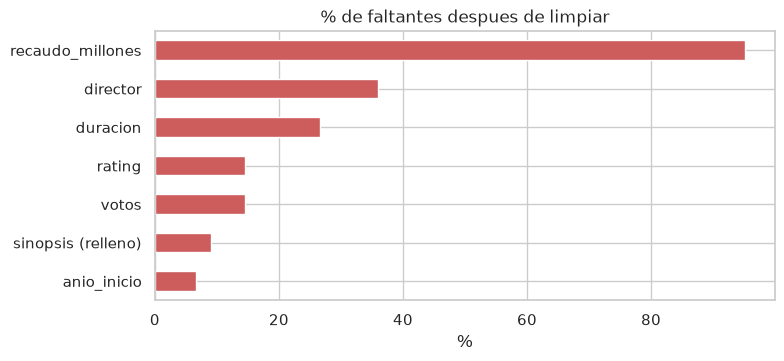

,% faltantes
anio_inicio,6.6
sinopsis (relleno),9.1
votos,14.6
rating,14.6
duracion,26.7
director,36.0
recaudo_millones,95.2


In [7]:
# Porcentaje de faltantes despues de limpiar en las columnas que interesan
faltantes = df[["rating", "votos", "duracion", "anio_inicio", "recaudo_millones"]].isna().mean() * 100
faltantes["sinopsis (relleno)"] = df["sin_sinopsis"].mean() * 100
faltantes["director"] = (df["tiene_director"] == 0).mean() * 100
faltantes = faltantes.round(1).sort_values()
faltantes.plot(kind="barh", color="indianred", figsize=(8, 3.5), title="% de faltantes despues de limpiar")
plt.xlabel("%")
plt.show()
faltantes.to_frame("% faltantes")

Con esos porcentajes se tomaron estas decisiones:

1. **Recaudo:** le falta cerca del 95 % de los datos. Imputar tanto sería inventar la columna, así que no se usa.
2. **Rating:** es la variable objetivo, así que las filas sin rating no sirven para entrenar y se eliminan. Casi todas son títulos que todavía no se estrenan, porque tampoco tienen votos.
3. **Duración y año:** se imputan más adelante con la mediana del conjunto de entrenamiento. La duración se imputa con la mediana de su mismo tipo, porque un episodio dura mucho menos que una película. Se hace después de separar entrenamiento y prueba para que ningún dato de prueba influya en el entrenamiento.
4. **Sinopsis y reparto faltantes:** no se eliminan, porque que falten también es información (suele pasar con títulos pequeños). Se dejan con banderas como `sin_sinopsis` y `tiene_director`.

In [8]:
# Solo los titulos con rating sirven para entrenar
d = df.dropna(subset=["rating"]).reset_index(drop=True)
d["log_votos"] = np.log1p(d["votos"])
print("Titulos con rating:", len(d), "de", len(df))

Titulos con rating: 8167 de 9567


## 3. Análisis exploratorio (EDA)

El análisis exploratorio se hizo sobre los 8167 títulos que tienen rating, siguiendo las herramientas vistas en clase: medidas de tendencia central, de dispersión y de posición, y después gráficos.

**Concepto: estadística descriptiva.** Sirve para resumir los datos antes de modelar y para detectar problemas. Las medidas de **tendencia central** (media, mediana, moda) dicen cuál es el valor típico. Las de **dispersión** (rango, varianza, desviación estándar) dicen qué tan separados están los datos. La media es sensible a los valores extremos y la mediana no, por eso conviene compararlas: si son muy distintas, la variable es asimétrica.

In [9]:
def medidas(serie):
    # Tendencia central y dispersion de una columna numerica
    s = serie.dropna()
    return pd.Series({
        "media": s.mean(), "mediana": s.median(), "moda": s.mode().iloc[0],
        "minimo": s.min(), "maximo": s.max(), "rango": s.max() - s.min(),
        "varianza": s.var(), "desviacion": s.std(), "coef_variacion": s.std() / s.mean(),
    })


numericas = ["rating", "duracion", "votos", "log_votos", "anio_inicio", "n_generos", "n_actores", "largo_sinopsis"]
# Se formatea con separador de miles para que la varianza de los votos no salga en notacion cientifica
d[numericas].apply(medidas).T.map(lambda v: f"{v:,.2f}")

,media,mediana,moda,minimo,maximo,rango,varianza,desviacion,coef_variacion
rating,6.92,7.10,7.20,1.10,9.90,8.80,1.49,1.22,0.18
duracion,69.46,60.00,24.00,1.00,853.00,852.00,"2,254.64",47.48,0.68
votos,"15,146.27",793.00,7.00,5.00,"1,713,028.00","1,713,023.00","4,914,519,563.70","70,103.63",4.63
log_votos,6.82,6.68,2.08,1.79,14.35,12.56,5.37,2.32,0.34
anio_inicio,"2,015.83","2,018.00","2,020.00","1,932.00","2,021.00",89.00,57.31,7.57,0.00
n_generos,2.26,3.00,3.00,1.00,3.00,2.00,0.71,0.84,0.37
n_actores,3.68,4.00,4.00,0.00,4.00,4.00,0.88,0.94,0.25
largo_sinopsis,24.70,25.00,24.00,0.00,70.00,70.00,83.86,9.16,0.37


La media del rating (6.92) es menor que la mediana (7.10) porque una cola de títulos con notas muy bajas arrastra el promedio hacia abajo. En los votos la diferencia es enorme: la media es 15146 y la mediana apenas 793, y la varianza pasa de cuatro mil millones. Unos pocos títulos muy famosos tienen cientos de miles de votos mientras la mayoría no llega a mil, y por eso su coeficiente de variación (desviación dividida entre la media) es 4.63, el más alto de la tabla.

En la duración la moda es 24 minutos, el largo típico de un episodio de comedia o animación, mientras la media es 69 minutos, porque en la misma columna se mezclan episodios y películas. `n_generos` y `n_actores` tienen como máximo 3 y 4 porque IMDb solo muestra esa cantidad en el listado.

**Concepto: percentiles.** El percentil k es el valor por debajo del cual queda el k % de los datos. Los cuartiles son los percentiles 25, 50 y 75. Mirar los percentiles extremos (1 y 99) ayuda a ver hasta dónde llegan las colas sin que un solo valor raro distorsione la lectura.

In [10]:
# Percentiles de las variables numericas
d[numericas].quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).T.round(1)

,0.01,0.10,0.25,0.50,0.75,0.90,0.99
rating,3.4,5.3,6.2,7.1,7.8,8.3,9.2
duracion,11.0,24.0,37.0,60.0,95.0,113.0,236.4
votos,8.0,49.0,167.0,793.0,3782.5,22211.8,297280.9
log_votos,2.2,3.9,5.1,6.7,8.2,10.0,12.6
anio_inicio,1979.7,2010.0,2015.0,2018.0,2020.0,2020.0,2021.0
n_generos,1.0,1.0,1.0,3.0,3.0,3.0,3.0
n_actores,0.0,3.0,4.0,4.0,4.0,4.0,4.0
largo_sinopsis,0.0,14.0,20.0,25.0,31.0,36.0,43.0


El 90 % de los títulos tiene un rating de 8.3 o menos y solo el 1 % pasa de 9.2. En los votos el percentil 50 es 793 y el percentil 99 es cercano a 300 mil, lo que confirma una cola muy larga. La duración tiene su percentil 99 en 236 minutos; por encima de ese valor solo quedan miniseries registradas con la suma de todos sus episodios. El año de inicio muestra que el dataset es muy reciente: la mitad de los títulos empezó en 2018 o después y solo el 10 % es anterior a 2010.

**Concepto: rango intercuartílico (IQR) y outliers.** El IQR es $Q3 - Q1$, el rango del 50 % central de los datos. Un valor se considera atípico si queda por debajo de $Q1 - 1.5 \cdot IQR$ o por encima de $Q3 + 1.5 \cdot IQR$. El **IQR ratio** (IQR dividido por el rango) resume la dispersión. Según lo visto en clase, menos de 0.05 indica una columna casi plana, entre 0.25 y 0.60 una dispersión sana, y más de 0.9 una dispersión tan grande que conviene transformar la variable.

In [11]:
def resumen_iqr(serie):
    # Cuartiles, limites de outliers, cantidad de outliers e IQR ratio
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    ratio = iqr / (s.max() - s.min())
    if ratio < 0.05:
        lectura = "casi plana"
    elif ratio > 0.9:
        lectura = "dispersion muy alta"
    elif 0.25 <= ratio <= 0.60:
        lectura = "dispersion sana"
    else:
        lectura = "intermedia"
    return pd.Series({"Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
                      "lim_inf": round(lim_inf, 2), "lim_sup": round(lim_sup, 2),
                      "outliers": int(((s < lim_inf) | (s > lim_sup)).sum()),
                      "% outliers": round(((s < lim_inf) | (s > lim_sup)).mean() * 100, 1),
                      "IQR_ratio": round(ratio, 3), "lectura": lectura})


d[numericas].apply(resumen_iqr).T

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,% outliers,IQR_ratio,lectura
rating,6.2,7.8,1.6,3.8,10.2,165,2.0,0.182,intermedia
duracion,37.0,95.0,58.0,-50.0,182.0,105,1.5,0.068,intermedia
votos,167.0,3782.5,3615.5,-5256.25,9205.75,1298,15.9,0.002,casi plana
log_votos,5.12,8.24,3.11,0.45,12.91,42,0.5,0.248,intermedia
anio_inicio,2015.0,2020.0,5.0,2007.5,2027.5,681,8.3,0.056,intermedia
n_generos,1.0,3.0,2.0,-2.0,6.0,0,0.0,1.0,dispersion muy alta
n_actores,4.0,4.0,0.0,4.0,4.0,951,11.6,0.0,casi plana
largo_sinopsis,20.0,31.0,11.0,3.5,47.5,383,4.7,0.157,intermedia


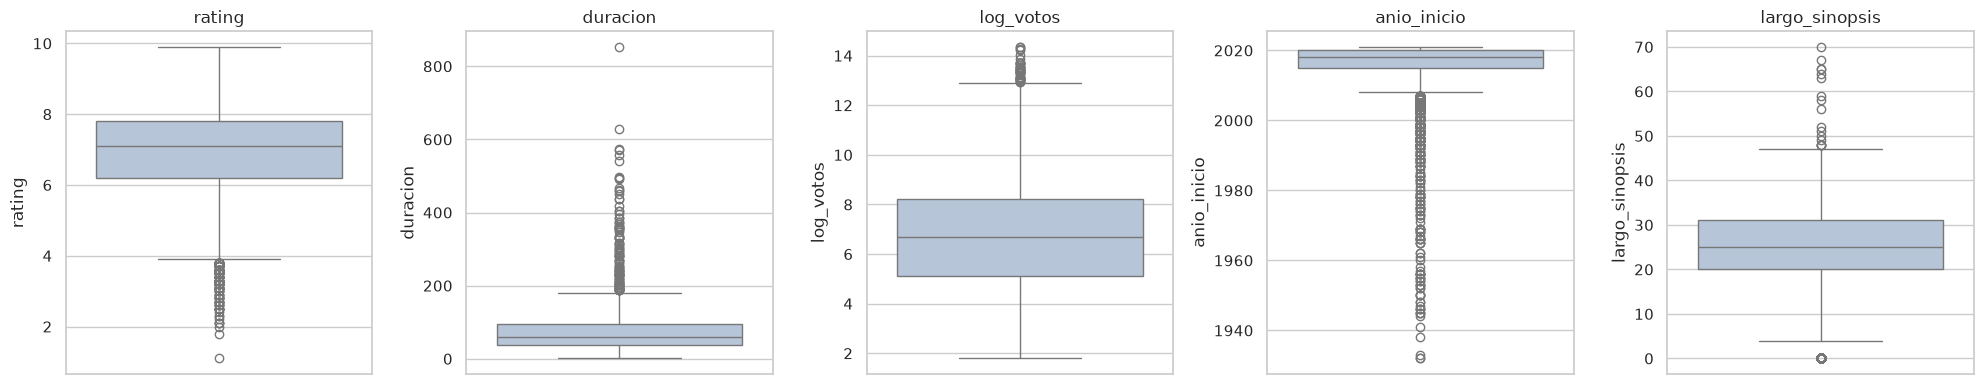

In [12]:
# Diagramas de caja para ver los outliers de forma grafica
fig, ejes = plt.subplots(1, 5, figsize=(20, 4))
for eje, col in zip(ejes, ["rating", "duracion", "log_votos", "anio_inicio", "largo_sinopsis"]):
    sns.boxplot(y=d[col], ax=eje, color="lightsteelblue")
    eje.set_title(col)
plt.tight_layout()
plt.show()

`votos` tiene un IQR ratio de 0.002 y cerca del 16 % de outliers, así que es la columna con la dispersión más problemática. Siguiendo la recomendación de clase para variables muy asimétricas, se le aplicó logaritmo, y `log_votos` queda con un IQR ratio de 0.248 y solo 42 outliers.

`n_actores` sale como casi plana (IQR de 0) porque la gran mayoría de títulos muestra exactamente 4 actores. Aun así se conservó, porque que falten actores sí dice algo: suele pasar en especiales, documentales y títulos pequeños. `n_generos` sale con dispersión muy alta, pero es un falso positivo de la regla: la columna solo puede valer 1, 2 o 3, así que el IQR cubre todo el rango.

Los outliers de `duracion` y del rating son reales (miniseries muy largas, cortos de pocos minutos y títulos muy mal calificados) y no errores de digitación, así que se conservaron. Según lo visto en clase, un dato atípico real se deja y solo se elimina cuando es un error.

**Concepto: histograma.** Muestra cuántos valores caen en cada intervalo de una variable numérica. Sirve para ver la forma de la distribución: si es simétrica, si tiene una cola larga o si tiene varios picos.

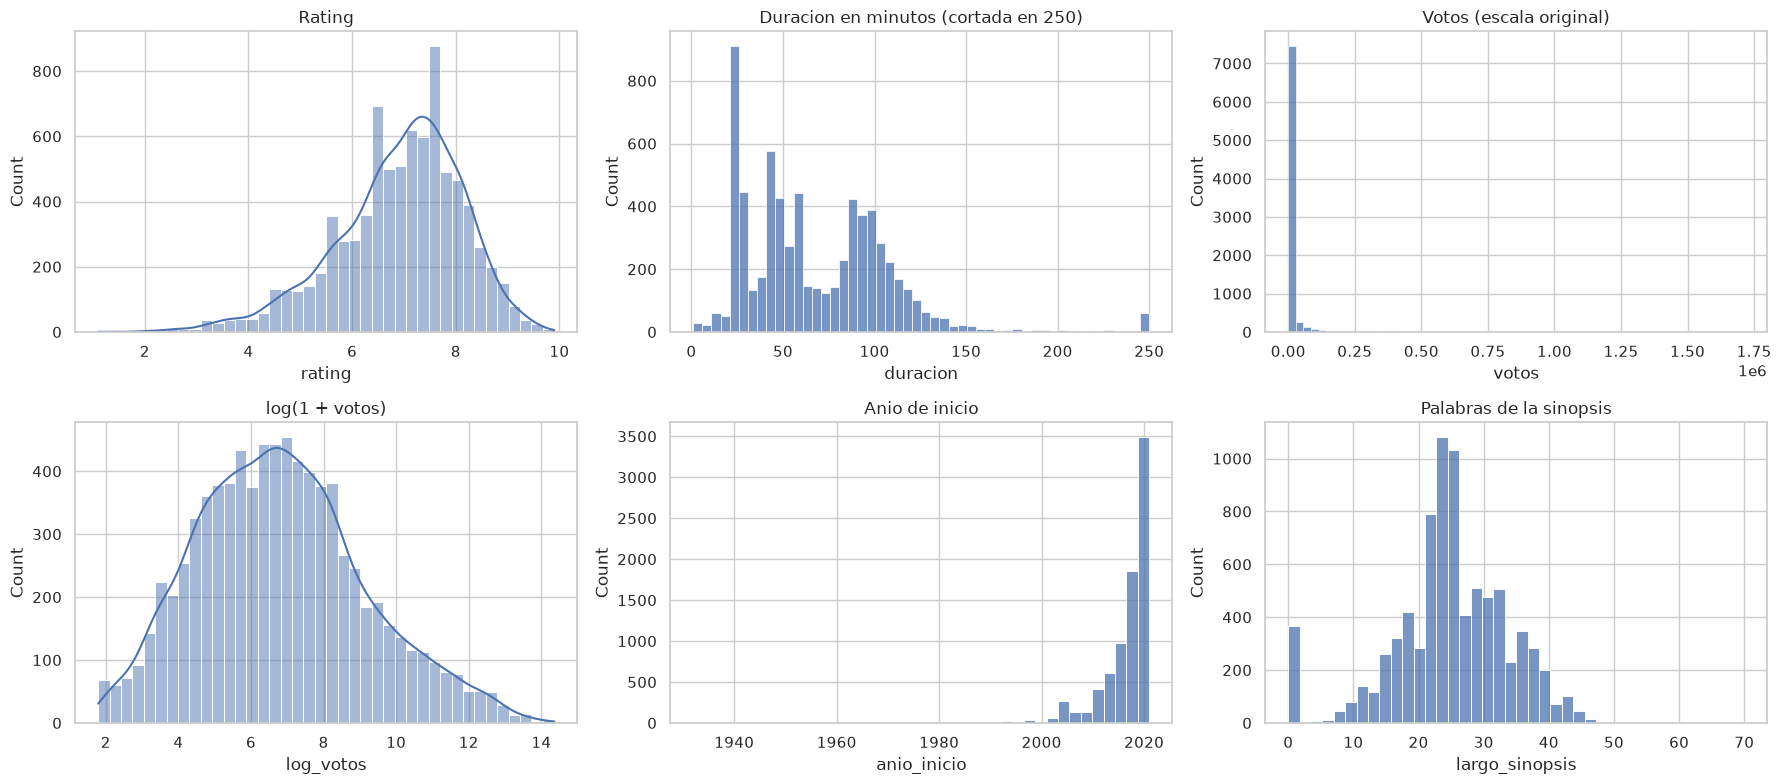

In [13]:
# Histogramas: distribucion de frecuencias de las variables numericas
fig, ejes = plt.subplots(2, 3, figsize=(18, 8))
sns.histplot(d["rating"], bins=40, kde=True, ax=ejes[0, 0]).set_title("Rating")
sns.histplot(d["duracion"].clip(upper=250), bins=50, ax=ejes[0, 1]).set_title("Duracion en minutos (cortada en 250)")
sns.histplot(d["votos"], bins=60, ax=ejes[0, 2]).set_title("Votos (escala original)")
sns.histplot(d["log_votos"], bins=40, kde=True, ax=ejes[1, 0]).set_title("log(1 + votos)")
sns.histplot(d["anio_inicio"].dropna(), bins=40, ax=ejes[1, 1]).set_title("Anio de inicio")
sns.histplot(d["largo_sinopsis"], bins=40, ax=ejes[1, 2]).set_title("Palabras de la sinopsis")
plt.tight_layout()
plt.show()

El rating tiene una distribución sesgada hacia la izquierda: la mayor parte está entre 6 y 8 y hay una cola hacia las notas bajas. La duración muestra dos picos, uno cerca de 20 a 25 minutos (episodios) y otro cerca de 90 a 100 minutos (películas). Los votos en su escala original son casi una sola barra pegada al cero, y después del logaritmo toman una forma parecida a una campana, mucho más fácil de usar en un modelo. El año de inicio se concentra en los últimos cinco años y la sinopsis suele tener entre 20 y 30 palabras, con un grupo en cero que corresponde a los títulos sin sinopsis.

**Concepto: gráfico de barras y gráfico circular.** El de barras compara la cantidad de cada categoría. El circular muestra qué proporción del total representa cada una, y solo se recomienda con pocas categorías (seis o siete como máximo), por eso los tipos muy pequeños se agruparon en *Otros*.

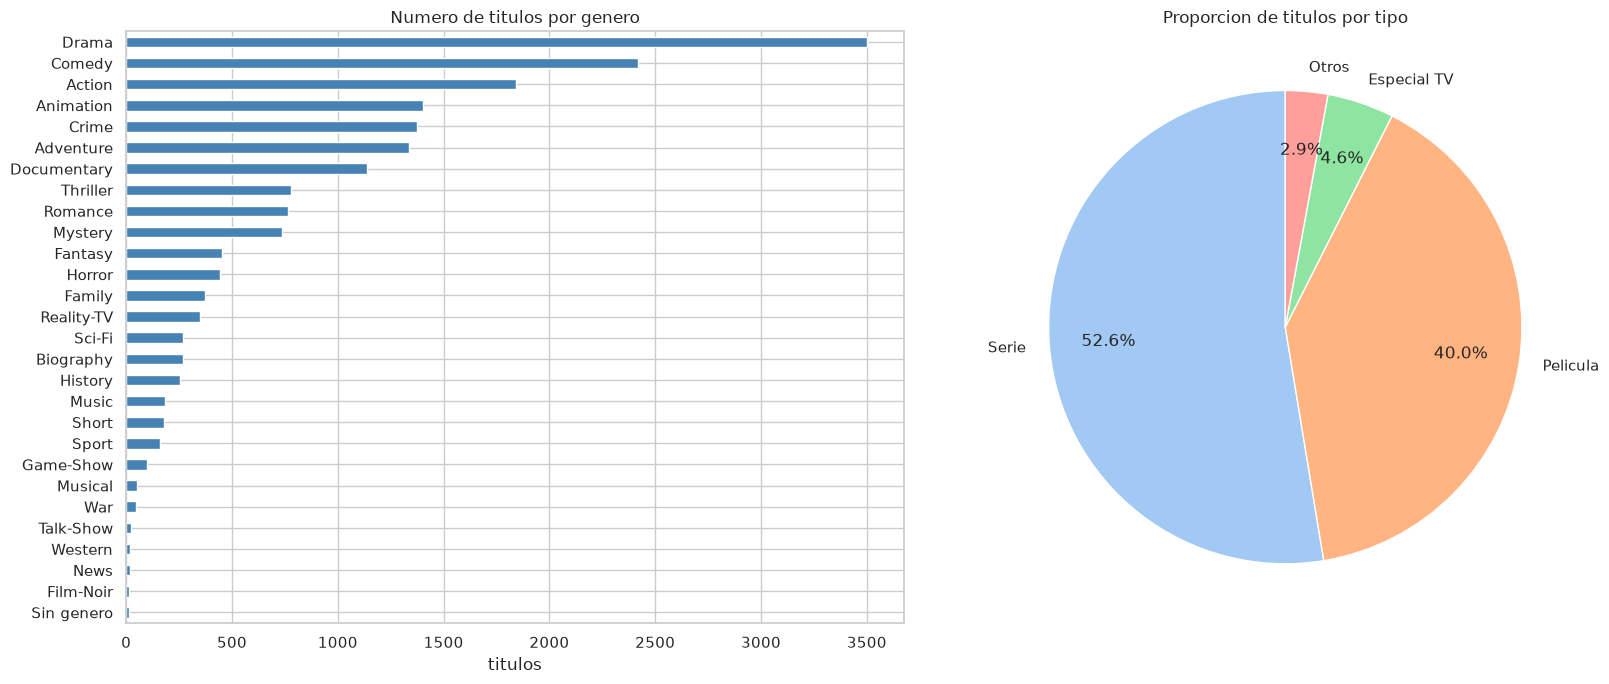

tipo
Serie          4296
Pelicula       3263
Especial TV     372
Pelicula TV     146
Video            83
Corto TV          7
Name: count, dtype: int64


In [14]:
# Grafico de barras de generos y grafico circular de tipos de produccion
conteo_generos = d["genero"].str.get_dummies(sep=", ").sum().sort_values()
conteo_tipos = d["tipo"].value_counts()

fig, ejes = plt.subplots(1, 2, figsize=(17, 7))
conteo_generos.plot(kind="barh", ax=ejes[0], color="steelblue")
ejes[0].set_title("Numero de titulos por genero")
ejes[0].set_xlabel("titulos")

# El circular agrupa los tipos pequenos (menos del 3 %) para que se pueda leer
grandes = conteo_tipos[conteo_tipos / conteo_tipos.sum() >= 0.03]
torta = pd.concat([grandes, pd.Series({"Otros": conteo_tipos.drop(grandes.index).sum()})])
ejes[1].pie(torta, labels=torta.index, autopct="%1.1f%%", startangle=90, pctdistance=0.75,
            colors=sns.color_palette("pastel"), wedgeprops={"edgecolor": "white"})
ejes[1].set_title("Proporcion de titulos por tipo")
plt.tight_layout()
plt.show()
print(conteo_tipos)

Drama es el género más frecuente (3499 títulos), seguido de comedia (2419) y acción (1842). Hay géneros con muy pocos títulos, como cine negro, western o noticias, que difícilmente le sirvan a un modelo.

En el gráfico circular se ve que el 52.6 % de los títulos con rating son series o episodios y el 40.0 % son películas. El dataset no es solo de películas, y como series y películas se comportan distinto en casi todas las variables, esta diferencia tiene que quedar representada en los modelos.

**Concepto: gráfico de dispersión.** Pone un punto por cada título con una variable en cada eje. Sirve para ver si dos variables numéricas se relacionan y de qué forma. El coeficiente de correlación de Pearson ($r$) mide qué tan fuerte es la relación **lineal**: vale 1 o $-1$ si los puntos forman una recta perfecta y 0 si no hay relación lineal.

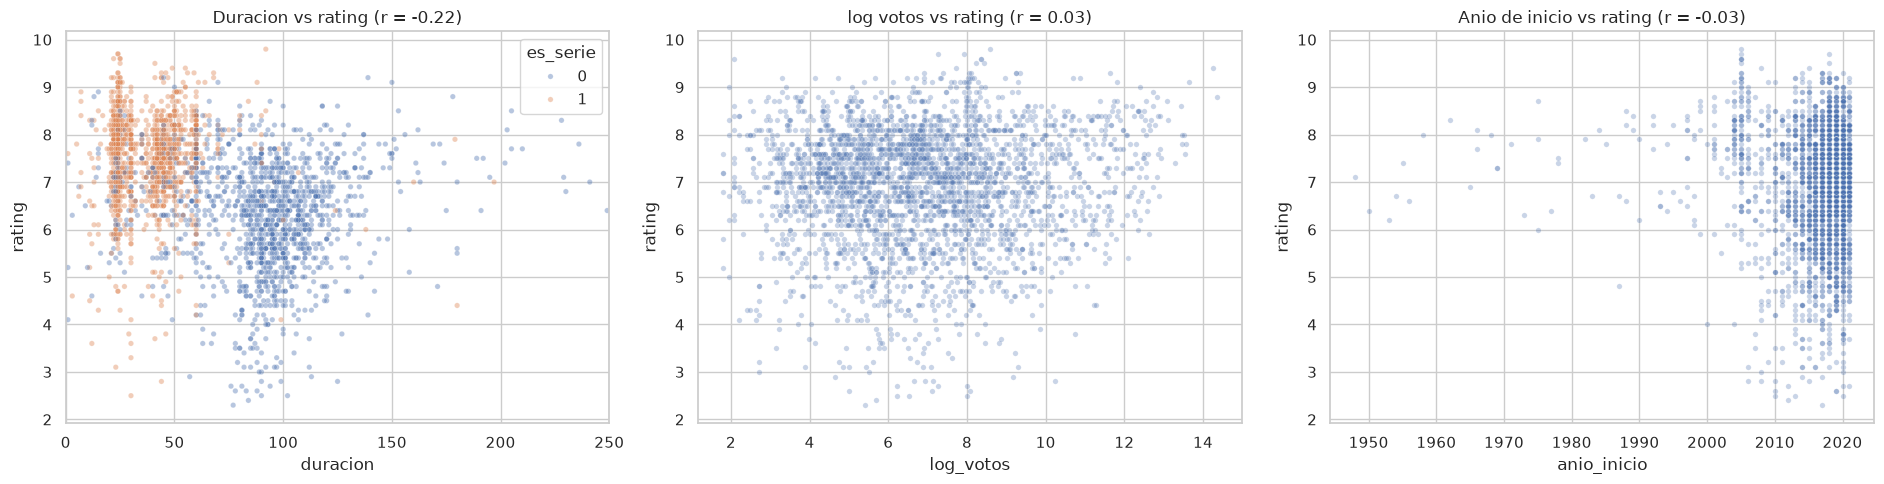

In [15]:
# Graficos de dispersion: relacion entre dos variables numericas
fig, ejes = plt.subplots(1, 3, figsize=(19, 5))
muestra = d.sample(3000, random_state=SEMILLA)  # muestra para que los puntos no se tapen
sns.scatterplot(data=muestra, x="duracion", y="rating", hue="es_serie", alpha=0.4, s=15, ax=ejes[0])
ejes[0].set_xlim(0, 250)
ejes[0].set_title(f"Duracion vs rating (r = {d['duracion'].corr(d['rating']):.2f})")
sns.scatterplot(data=muestra, x="log_votos", y="rating", alpha=0.3, s=15, ax=ejes[1])
ejes[1].set_title(f"log votos vs rating (r = {d['log_votos'].corr(d['rating']):.2f})")
sns.scatterplot(data=muestra, x="anio_inicio", y="rating", alpha=0.3, s=15, ax=ejes[2])
ejes[2].set_title(f"Anio de inicio vs rating (r = {d['anio_inicio'].corr(d['rating']):.2f})")
plt.tight_layout()
plt.show()

Ninguna de las tres nubes de puntos muestra una relación lineal fuerte. La duración tiene una correlación negativa de 0.22 con el rating: los episodios cortos (las series, en otro color) quedan más arriba que las películas. Los votos y el año tienen una correlación prácticamente nula. En el gráfico de votos sí se nota que los títulos con muy pocos votos tienen ratings mucho más dispersos: cuando votan pocas personas, la nota es poco estable.

**Concepto: mapa de calor.** Muestra una matriz con colores. Aquí se usó para la matriz de correlación: los tonos rojos son correlaciones positivas y los azules negativas. Sirve para ver de un vistazo qué variables se relacionan con el rating y cuáles son redundantes entre sí.

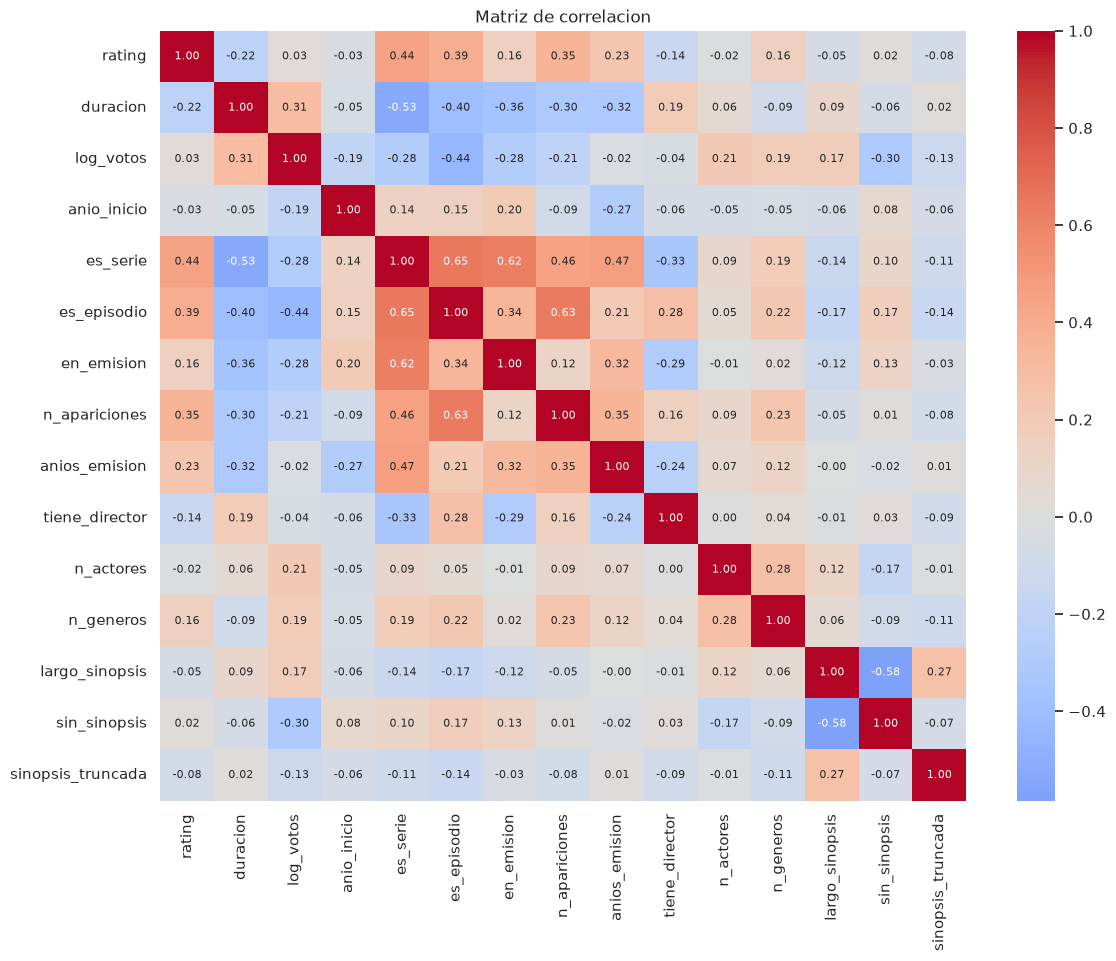

,correlacion con rating
duracion,-0.224
tiene_director,-0.142
sinopsis_truncada,-0.077
largo_sinopsis,-0.052
anio_inicio,-0.029
n_actores,-0.018
sin_sinopsis,0.019
log_votos,0.034
n_generos,0.157
en_emision,0.162


In [16]:
# Mapa de calor con la correlacion de Pearson entre variables numericas
cols_corr = ["rating", "duracion", "log_votos", "anio_inicio", "es_serie", "es_episodio", "en_emision",
             "n_apariciones", "anios_emision", "tiene_director", "n_actores", "n_generos",
             "largo_sinopsis", "sin_sinopsis", "sinopsis_truncada"]
plt.figure(figsize=(13, 10))
sns.heatmap(d[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 8})
plt.title("Matriz de correlacion")
plt.show()
d[cols_corr].corr()["rating"].drop("rating").sort_values().round(3).to_frame("correlacion con rating")

Las variables más relacionadas con el rating son `es_serie` (0.44), `es_episodio` (0.39) y `n_apariciones` (0.36), todas ligadas a si el título es una serie. La duración tiene la correlación negativa más fuerte (0.22), seguida de `tiene_director` (0.14). En el mapa también se ven variables redundantes entre sí: `es_serie`, `es_episodio`, `n_apariciones` y `tiene_director` están bastante correlacionadas, porque las películas y los episodios traen director en el reparto y las series completas no.

Varias variables tienen una correlación casi nula con el rating, como los votos, el año o el largo de la sinopsis. Eso anticipa que un modelo con solo estas columnas va a explicar una parte limitada del rating.

**Concepto: gráfico de radar.** Dibuja varias variables sobre ejes que salen del centro, uno por variable, y une los valores de cada grupo formando un polígono. Sirve para comparar el perfil completo de varios grupos. Como las variables tienen escalas distintas, cada una se normalizó entre 0 y 1.

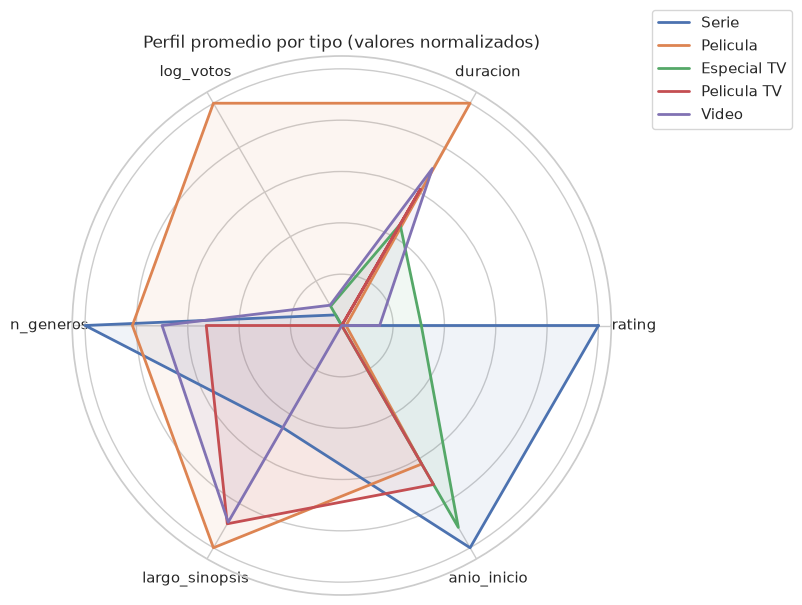

,rating,duracion,log_votos,n_generos,largo_sinopsis,anio_inicio
tipo,,,,,,
Especial TV,6.65,66.84,6.27,1.28,20.90,2016.30
Pelicula,6.31,96.65,7.74,2.20,26.61,2014.59
Pelicula TV,6.29,75.46,6.13,1.88,25.99,2015.14
Serie,7.43,41.98,6.20,2.41,23.52,2016.85
Video,6.46,80.60,6.28,2.07,25.95,2010.84


In [17]:
# Grafico de radar: perfil promedio de cada tipo de produccion
dimensiones = ["rating", "duracion", "log_votos", "n_generos", "largo_sinopsis", "anio_inicio"]
tipos_radar = ["Serie", "Pelicula", "Especial TV", "Pelicula TV", "Video"]
perfil = d[d["tipo"].isin(tipos_radar)].groupby("tipo")[dimensiones].mean()
# Se normaliza cada dimension entre 0 y 1 para poder comparar escalas distintas
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

angulos = np.linspace(0, 2 * np.pi, len(dimensiones), endpoint=False).tolist()
angulos += angulos[:1]
fig = plt.figure(figsize=(7, 7))
eje = plt.subplot(polar=True)
for tipo in tipos_radar:
    valores = perfil_norm.loc[tipo].tolist()
    valores += valores[:1]
    eje.plot(angulos, valores, lw=2, label=tipo)
    eje.fill(angulos, valores, alpha=0.08)
eje.set_xticks(angulos[:-1])
eje.set_xticklabels(dimensiones)
eje.set_yticklabels([])
eje.set_title("Perfil promedio por tipo (valores normalizados)")
eje.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.show()
perfil.round(2)

Los perfiles son muy distintos. Las series tienen el rating promedio más alto (7.43), la menor duración (42 minutos) y el mayor número de géneros. Las películas son las más largas (97 minutos) y las que más votos reciben, pero tienen el rating más bajo junto con las películas de TV (6.31 y 6.29). Los especiales de TV tienen pocos géneros y sinopsis más cortas, y los videos son los títulos más antiguos en promedio. El tipo de producción resume mucha información, por eso se usa como variable en los modelos.

**Concepto: serie de tiempo.** Muestra cómo cambia una variable a lo largo del tiempo, con el tiempo ordenado en el eje horizontal. Aquí se usó el año de inicio de cada título.

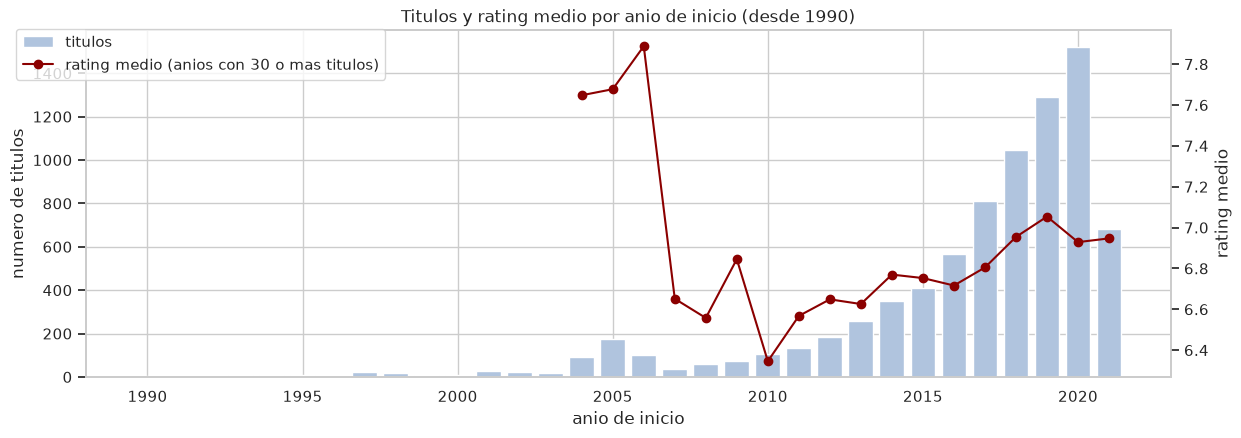

anio_inicio,2004.0,2005.0,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0
titulos,92.00,173.00,99.00,35.00,59.00,75.00,105.00,132.00,183.00,257.00,348.00,411.00,565.00,811.0,1044.00,1291.00,1521.00,684.00
rating_medio,7.65,7.68,7.89,6.65,6.56,6.85,6.35,6.57,6.65,6.63,6.77,6.75,6.72,6.8,6.95,7.05,6.93,6.95


In [18]:
# Serie de tiempo: titulos por anio de inicio y rating promedio de esos titulos
por_anio = (d[d["anio_inicio"] >= 1990].groupby("anio_inicio")
            .agg(titulos=("rating", "size"), rating_medio=("rating", "mean")))
# El promedio solo se dibuja en los anios con al menos 30 titulos, porque con pocos titulos es muy inestable
estable = por_anio[por_anio["titulos"] >= 30]

fig, eje1 = plt.subplots(figsize=(14, 4.5))
eje1.bar(por_anio.index, por_anio["titulos"], color="lightsteelblue", label="titulos")
eje1.set_ylabel("numero de titulos")
eje2 = eje1.twinx()
eje2.plot(estable.index, estable["rating_medio"], color="darkred", marker="o", label="rating medio (anios con 30 o mas titulos)")
eje2.set_ylabel("rating medio")
eje2.grid(False)
eje1.set_xlabel("anio de inicio")
plt.title("Titulos y rating medio por anio de inicio (desde 1990)")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.9))
plt.show()
estable.round(2).T

La cantidad de títulos crece muy rápido desde 2014 y llega a su máximo en 2020 con 1521 títulos. 2021 aparece más bajo, probablemente porque los datos se tomaron durante ese año. El 77 % de los títulos con rating empezó en 2015 o después.

El rating medio solo se dibujó en los años con al menos 30 títulos, porque con menos el promedio salta demasiado. Los títulos que empezaron antes de 2010 tienen un promedio de 7.31, más alto que los de 2010 a 2014 (6.64) y los de 2015 en adelante (6.91). Los picos de 2004 a 2006 se explican porque el 69 % de esos títulos son episodios de series largas y exitosas, como Bleach, Avatar: The Last Airbender o Dexter. Es un sesgo de supervivencia: de los años viejos solo quedan en el listado los títulos que tuvieron éxito, mientras que de los años recientes está casi todo.

### Análisis de la variable objetivo

Como en este notebook se predice el rating, se revisó cómo cambia según el tipo de título, según si es serie o episodio y según el género.

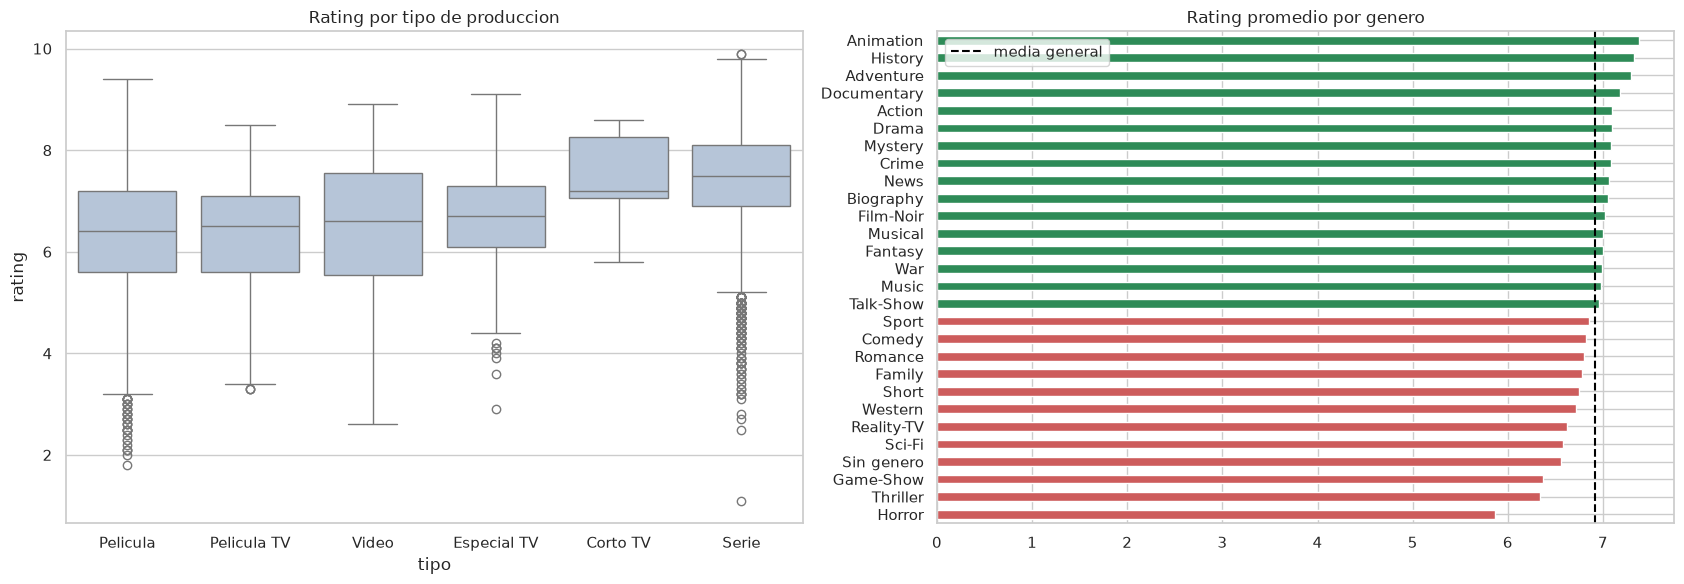

,count,mean,median,std
Episodio,2608,7.62,7.6,0.89
Pelicula u otro,3871,6.35,6.5,1.19
Serie completa,1688,7.14,7.3,1.10


In [19]:
# Rating segun el tipo de produccion y segun el genero
fig, ejes = plt.subplots(1, 2, figsize=(17, 6))
orden = d.groupby("tipo")["rating"].median().sort_values().index
sns.boxplot(data=d, x="tipo", y="rating", order=orden, ax=ejes[0], color="lightsteelblue")
ejes[0].set_title("Rating por tipo de produccion")

generos_d = d["genero"].str.get_dummies(sep=", ")
media_genero = pd.Series({g: d.loc[generos_d[g] == 1, "rating"].mean() for g in generos_d.columns}).sort_values()
media_genero.plot(kind="barh", ax=ejes[1], color=np.where(media_genero > d["rating"].mean(), "seagreen", "indianred"))
ejes[1].axvline(d["rating"].mean(), color="black", ls="--", label="media general")
ejes[1].set_title("Rating promedio por genero")
ejes[1].legend()
plt.tight_layout()
plt.show()

# Rating promedio de peliculas, series completas y episodios
grupo = np.select([d["es_episodio"] == 1, d["es_serie"] == 1], ["Episodio", "Serie completa"], "Pelicula u otro")
d.groupby(grupo)["rating"].agg(["count", "mean", "median", "std"]).round(2)

El rating mediano de las series es claramente mayor que el de las películas. Por grupos, los episodios tienen un promedio de 7.62, las series completas 7.14 y las películas y demás títulos 6.35. Los episodios tienen además la menor desviación (0.89), porque los episodios de una misma serie suelen tener notas parecidas.

Por género también hay diferencias claras: terror (5.86), thriller (6.33) y concursos quedan muy por debajo del promedio, mientras que animación (7.38), historia (7.33) y aventura (7.30) quedan por encima.

### Resumen del análisis exploratorio

1. El rating se concentra entre 6 y 8, con una cola hacia las notas bajas.
2. Lo que más se relaciona con el rating es la estructura del título: las series y los episodios tienen mejor nota que las películas. La duración tiene una relación negativa porque separa episodios de películas.
3. Los votos tienen una distribución extremadamente asimétrica y necesitan logaritmo. Aun así, su relación lineal con el rating es casi nula.
4. Los outliers son datos reales y se conservaron.
5. El género cambia el rating promedio hasta en un punto y medio.
6. Ninguna variable original tiene una correlación mayor a 0.45 con el rating, así que se espera que una sola variable explique poco y que el modelo mejore al combinar varias, incluyendo las que se construyen a partir del texto.

## 4. Preparación de los datos para los modelos

### División entrenamiento y prueba

**Concepto.** Los datos se dividen en entrenamiento y prueba para medir el modelo con títulos que nunca vio. Si se evaluara con los mismos datos del entrenamiento, las métricas saldrían infladas.

Los episodios de una misma serie se parecen mucho entre sí: comparten título, reparto, duración y género. Con una división aleatoria normal, unos episodios quedarían en entrenamiento y otros en prueba, y el modelo reconocería la serie en vez de aprender algo general. Por eso se usó `GroupShuffleSplit` agrupando por título: todos los episodios de una serie quedan del mismo lado. Se dejó el 80 % para entrenar y el 20 % para probar.

In [20]:
# Division 80/20 agrupando por titulo
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(d, groups=d["titulo"]))
train, test = d.iloc[idx_train].copy(), d.iloc[idx_test].copy()
print("Entrenamiento:", len(train), "filas | Prueba:", len(test), "filas")
print("Titulos compartidos entre ambos:", len(set(train["titulo"]) & set(test["titulo"])))

Entrenamiento: 6526 filas | Prueba: 1641 filas
Titulos compartidos entre ambos: 0


### Imputación y variables derivadas

La duración y el año faltantes se llenaron con medianas calculadas **solo con el entrenamiento** y aplicadas igual a prueba. Así ninguna información de prueba se filtra al modelo. También se crearon estas variables:

1. `log_votos_anio`: los votos divididos entre los años que lleva el título publicado, en logaritmo. Un título de 2021 con 5000 votos es más popular que uno de 2005 con los mismos votos.
2. `log_apariciones`: logaritmo de cuántas filas tiene el título. Una serie con muchos episodios listados suele ser una serie con muchos seguidores.
3. **Géneros y tipo en one hot:** una columna 0/1 por cada categoría. Un título puede tener varios géneros a la vez. Del tipo se deja por fuera `Pelicula`, que queda como categoría base, y `Serie`, que ya está en `es_serie`. Si se dejaran todas, una columna sería combinación exacta de las otras, y eso daña la regresión lineal.
4. **Rangos de duración:** la duración se dividió en intervalos (0 a 15 minutos, 15 a 30, etc.) y cada intervalo quedó como columna 0/1. Esto se llama **discretización** y sirve para que un modelo lineal pueda representar relaciones que no son una recta. En el análisis exploratorio se vio que el rating sube en los episodios de 20 a 60 minutos, baja en las películas de 90 minutos y vuelve a subir en las miniseries largas.

In [21]:
CORTES_DURACION = [0, 15, 30, 50, 70, 85, 100, 130, 180, np.inf]
ETQ_DURACION = ["0_15", "15_30", "30_50", "50_70", "70_85", "85_100", "100_130", "130_180", "180_mas"]


def imputar_y_derivar(train, test):
    # Las medianas salen solo del entrenamiento
    mediana_tipo = train.groupby("tipo")["duracion"].median()
    mediana_duracion = train["duracion"].median()
    mediana_anio = train["anio_inicio"].median()
    partes = []
    for parte in (train, test):
        p = parte.copy()
        p["duracion_faltante"] = p["duracion"].isna().astype(int)
        p["duracion"] = p["duracion"].fillna(p["tipo"].map(mediana_tipo)).fillna(mediana_duracion)
        p["anio_inicio"] = p["anio_inicio"].fillna(mediana_anio)
        p["log_votos_anio"] = np.log1p(p["votos"] / (2022 - p["anio_inicio"]).clip(lower=1))
        p["log_apariciones"] = np.log(p["n_apariciones"])
        # Rangos de duracion en one hot
        rangos = pd.cut(p["duracion"], bins=CORTES_DURACION, labels=ETQ_DURACION)
        p = pd.concat([p, pd.get_dummies(rangos, prefix="dur", dtype=int)], axis=1)
        partes.append(p)
    return partes


def one_hot(train, test):
    # Generos y tipo en columnas 0/1 con las mismas columnas en ambos conjuntos
    generos = sorted(set(g for lista in train["genero"].str.split(", ") for g in lista))
    tipos = [t for t in sorted(train["tipo"].unique()) if t not in ("Pelicula", "Serie")]
    cols_gen = ["gen_" + g.replace("-", "_").replace(" ", "_") for g in generos]
    cols_tipo = ["tipo_" + t.replace(" ", "_") for t in tipos]
    for p in (train, test):
        lista = p["genero"].str.split(", ")
        for g, c in zip(generos, cols_gen):
            p[c] = lista.apply(lambda x: int(g in x))
        for t, c in zip(tipos, cols_tipo):
            p[c] = (p["tipo"] == t).astype(int)
    return cols_gen, cols_tipo


train, test = imputar_y_derivar(train, test)
cols_generos, cols_tipos = one_hot(train, test)
cols_duracion = ["dur_" + e for e in ETQ_DURACION]
print("Generos:", len(cols_generos), "| tipos:", cols_tipos)

Generos: 28 | tipos: ['tipo_Corto_TV', 'tipo_Especial_TV', 'tipo_Pelicula_TV', 'tipo_Video']


### Historial del director, de los actores y puntaje de la sinopsis

El análisis exploratorio mostró que las variables del archivo explican solo una parte del rating. Lo que más pesa en la calificación de una película, como quién la dirige, quién actúa y de qué trata, viene como texto. Para aprovecharlo se crearon tres tipos de variables nuevas.

**Concepto: codificación por objetivo (target encoding).** Cada director o actor se reemplaza por el rating promedio de los otros títulos en los que participó. Sirve para convertir miles de nombres distintos en un solo número con significado. Por ejemplo, un director cuyas otras obras tienen un promedio de 8 probablemente haga títulos bien calificados. Se aplicaron dos cuidados:

1. **Suavizado:** si una persona tiene muy pocos títulos, su promedio no es confiable. Por eso se mezcla con el promedio general usando $\frac{\text{suma} + k \cdot \text{media global}}{n + k}$ con $k = 5$. Con pocos títulos el valor queda cerca del promedio general, y con muchos títulos pesa el promedio propio.
2. **Cálculo fuera de pliegue (out of fold):** si el rating de un título se usara para calcular su propia variable, el modelo estaría viendo la respuesta. Por eso el entrenamiento se dividió en 5 partes agrupadas por título y el valor de cada parte se calculó solo con las otras cuatro. Para el conjunto de prueba se usó todo el entrenamiento.

Además se guardó cuántos títulos previos tiene cada persona (`log_exp_director` y `log_exp_actores`), porque la experiencia también puede influir.

**Concepto: TF IDF.** Convierte un texto en números: cada palabra (o pareja de palabras) recibe un peso que es alto si aparece mucho en ese texto pero poco en el resto. Se aplicó a la sinopsis junto con el género, y sobre esa representación se entrenó una regresión Ridge (regresión lineal con regularización) que predice el rating. Esa predicción quedó como una sola columna, `puntaje_texto`, calculada también fuera de pliegue. Así los modelos del taller reciben la información del texto sin tener que manejar miles de columnas.

In [22]:
def codificar_personas(ajuste, aplicar, columna, media, k=5):
    # Promedio suavizado del rating de cada persona, usando solo las filas de "ajuste"
    filas = ajuste[[columna, "titulo", "rating"]].explode(columna).dropna(subset=[columna])
    filas = filas.groupby([columna, "titulo"])["rating"].mean().reset_index()  # un voto por titulo
    estad = filas.groupby(columna)["rating"].agg(["sum", "count"])
    suavizado = (estad["sum"] + k * media) / (estad["count"] + k)

    def valor(lista):
        conocidos = [p for p in lista if p in suavizado.index]
        promedio = np.mean([suavizado[p] for p in conocidos]) if conocidos else media
        return promedio, estad.loc[conocidos, "count"].sum() if conocidos else 0

    resultado = aplicar[columna].apply(valor)
    return resultado.str[0].to_numpy(), resultado.str[1].to_numpy()


def texto_de(df):
    return (df["sinopsis"] + " " + df["genero"]).to_numpy()


def modelo_texto(ajuste):
    # TF IDF de la sinopsis y el genero, y una regresion Ridge que predice el rating
    tfidf = TfidfVectorizer(min_df=3, ngram_range=(1, 2), stop_words="english", sublinear_tf=True)
    ridge = Ridge(alpha=3).fit(tfidf.fit_transform(texto_de(ajuste)), ajuste["rating"])
    return lambda df: ridge.predict(tfidf.transform(texto_de(df)))


def agregar_codificaciones(train, test, pliegues=5):
    nuevas = ["te_director", "te_actores", "exp_director", "exp_actores", "puntaje_texto"]
    for c in nuevas:
        train[c] = 0.0
    # Fuera de pliegue: cada parte del entrenamiento se calcula con las otras cuatro
    for idx_ajuste, idx_aplicar in GroupKFold(pliegues).split(train, groups=train["titulo"]):
        ajuste, aplicar = train.iloc[idx_ajuste], train.iloc[idx_aplicar]
        media = ajuste["rating"].mean()
        for columna, nombre in [("directores", "director"), ("actores", "actores")]:
            valor, conteo = codificar_personas(ajuste, aplicar, columna, media)
            train.iloc[idx_aplicar, train.columns.get_loc("te_" + nombre)] = valor
            train.iloc[idx_aplicar, train.columns.get_loc("exp_" + nombre)] = conteo
        train.iloc[idx_aplicar, train.columns.get_loc("puntaje_texto")] = modelo_texto(ajuste)(aplicar)
    # El conjunto de prueba se calcula con todo el entrenamiento
    media = train["rating"].mean()
    for columna, nombre in [("directores", "director"), ("actores", "actores")]:
        test["te_" + nombre], test["exp_" + nombre] = codificar_personas(train, test, columna, media)
    test["puntaje_texto"] = modelo_texto(train)(test)
    for p in (train, test):
        p["log_exp_director"] = np.log1p(p["exp_director"])
        p["log_exp_actores"] = np.log1p(p["exp_actores"])


agregar_codificaciones(train, test)
print("Titulos de prueba con algun actor conocido:", round((test["exp_actores"] > 0).mean() * 100, 1), "%")
print("Titulos de prueba con director conocido:", round((test["exp_director"] > 0).mean() * 100, 1), "%")
train[["titulo", "rating", "te_director", "te_actores", "puntaje_texto"]].head()

Titulos de prueba con algun actor conocido: 68.5 %
Titulos de prueba con director conocido: 19.9 %


,titulo,rating,te_director,te_actores,puntaje_texto
0,Blood Red Sky,6.1,6.908504,7.023753,4.855131
1,Masters of the Universe: Revelation,5.0,6.895613,6.840653,6.944161
2,The Walking Dead,8.2,6.908504,6.890420,6.036812
3,Rick and Morty,9.2,6.903007,7.001136,6.480148
4,Outer Banks,7.6,6.923386,6.923386,6.463898


In [23]:
# Correlacion de las variables nuevas con el rating, medida en entrenamiento
nuevas = ["te_director", "te_actores", "log_exp_director", "log_exp_actores", "puntaje_texto",
          "log_votos_anio", "log_apariciones"]
train[nuevas + ["rating"]].corr()["rating"].drop("rating").sort_values().round(3).to_frame("correlacion con rating")

,correlacion con rating
log_exp_director,-0.046
log_votos_anio,0.037
log_exp_actores,0.073
te_director,0.190
te_actores,0.233
puntaje_texto,0.350
log_apariciones,0.407


Las variables nuevas sí se relacionan con el rating. `puntaje_texto` llega a una correlación de 0.35, más alta que cualquier variable numérica original salvo las de estructura de serie. `te_actores` (0.23) y `te_director` (0.19) también aportan, aunque solo el 68.5 % de los títulos de prueba tiene algún actor conocido y apenas el 19.9 % tiene un director conocido; en el resto la variable queda en el promedio general. La cantidad de títulos previos del director o de los actores casi no se relaciona con el rating. `log_apariciones` (0.41) confirma que las series con muchos episodios listados tienden a estar mejor calificadas.

In [24]:
# Grupos de variables que se usan en los modelos
vars_estructura = ["es_serie", "es_episodio", "en_emision", "log_apariciones", "anios_emision"]
vars_extra = ["anio_inicio", "log_votos_anio", "tiene_director", "n_directores", "n_actores", "n_generos",
              "largo_sinopsis", "sin_sinopsis", "sinopsis_truncada", "duracion_faltante"]
vars_personas_texto = ["te_director", "te_actores", "log_exp_director", "log_exp_actores", "puntaje_texto"]
todas = ["duracion", "log_votos"] + vars_estructura + vars_extra + vars_personas_texto + cols_generos + cols_tipos

# Variables candidatas para los casos con una y dos columnas
candidatas = ["duracion", "log_votos", "es_serie", "es_episodio", "log_apariciones", "anios_emision",
              "tiene_director", "anio_inicio", "log_votos_anio", "te_director", "te_actores", "puntaje_texto"]
cv = GroupKFold(n_splits=5)
print("Columnas caracteristica disponibles:", len(todas))

Columnas caracteristica disponibles: 54


## 5. Métricas de evaluación

**R² (coeficiente de determinación):** mide qué proporción de la variación del rating logra explicar el modelo. Vale 1 si el modelo es perfecto y 0 si no mejora a predecir siempre el promedio; en datos nuevos puede salir negativo.

**MSE (error cuadrático medio):** es $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$, el promedio de los errores al cuadrado. Castiga más los errores grandes. También se reporta el **RMSE**, su raíz, que queda en las mismas unidades del rating y se interpreta más fácil.

**R:** coeficiente de correlación entre el valor real y el predicho.

Las métricas se calculan sobre el conjunto de prueba. También se muestra el R² de entrenamiento para revisar si hay sobreajuste.

In [25]:
def evaluar_regresion(columnas, nombre):
    # Entrena la regresion lineal con las columnas dadas y calcula las metricas
    modelo = LinearRegression().fit(train[columnas], train["rating"])
    pred = modelo.predict(test[columnas])
    mse = mean_squared_error(test["rating"], pred)
    metricas = {
        "modelo": nombre,
        "n_variables": len(columnas),
        "R": np.corrcoef(test["rating"], pred)[0, 1],
        "R2_train": r2_score(train["rating"], modelo.predict(train[columnas])),
        "R2_test": r2_score(test["rating"], pred),
        "MSE_test": mse,
        "RMSE_test": np.sqrt(mse),
    }
    return modelo, pred, metricas


def r2_validacion(columnas):
    # R2 promedio en validacion cruzada de 5 partes, solo con el entrenamiento y agrupando por titulo
    return cross_val_score(LinearRegression(), train[columnas], train["rating"],
                           groups=train["titulo"], cv=cv, scoring="r2").mean()


# Referencia: predecir siempre el promedio del entrenamiento
mse_base = mean_squared_error(test["rating"], np.full(len(test), train["rating"].mean()))
print(f"Modelo base (siempre el promedio): MSE = {mse_base:.3f}, RMSE = {np.sqrt(mse_base):.3f}")

Modelo base (siempre el promedio): MSE = 1.488, RMSE = 1.220


## 6. Caso 1: regresión lineal simple

**Enunciado.** Aplicar regresión lineal seleccionando una única columna característica y una variable objetivo, obtener métricas de desempeño (R, MSE), redactar los procesos relevantes y sacar conclusiones.

**Variable objetivo:** `rating`.

**Selección de la variable característica.** En lugar de escoger la columna a ojo, se probó una regresión con cada una de las 12 variables candidatas y se midió su R² con **validación cruzada** dentro del entrenamiento. La validación cruzada divide el entrenamiento en 5 partes, entrena con cuatro y evalúa con la quinta, rotando las partes. Así la elección no depende del conjunto de prueba, que se reserva para la evaluación final.

In [26]:
# R2 en validacion cruzada de cada variable candidata por separado
r2_una = pd.Series({c: r2_validacion([c]) for c in candidatas}).sort_values(ascending=False)
var_1 = r2_una.index[0]
print("Variable elegida:", var_1)
r2_una.round(4).to_frame("R2 en validacion cruzada")

Variable elegida: es_serie


,R2 en validacion cruzada
es_serie,0.1832
log_apariciones,0.1630
es_episodio,0.1450
puntaje_texto,0.1203
duracion,0.0530
te_actores,0.0479
anios_emision,0.0451
te_director,0.0336
tiene_director,0.0161
log_votos,-0.0009


In [27]:
modelo_1, pred_1, met_1 = evaluar_regresion([var_1], f"Caso 1: {var_1}")
print(f"Intercepto: {modelo_1.intercept_:.4f}")
print(f"Coeficiente de {var_1}: {modelo_1.coef_[0]:.4f}")
pd.DataFrame([met_1]).round(4)

Intercepto: 6.3591
Coeficiente de es_serie: 1.0509


,modelo,n_variables,R,R2_train,R2_test,MSE_test,RMSE_test
0,Caso 1: es_serie,1,0.4944,0.1851,0.2393,1.1296,1.0628


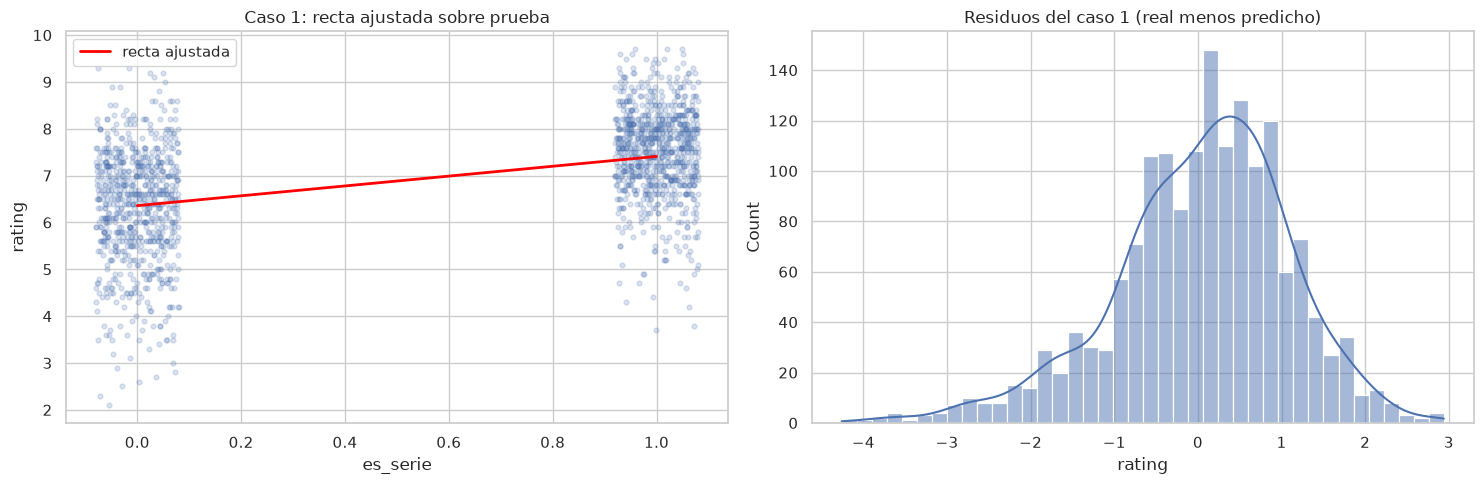

In [28]:
# Datos de prueba y recta ajustada (se agrega un pequeno ruido horizontal para que los puntos no se tapen)
ruido = np.random.default_rng(SEMILLA).uniform(-0.08, 0.08, len(test))
x_linea = np.linspace(test[var_1].min(), test[var_1].max(), 50)

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))
ejes[0].scatter(test[var_1] + ruido, test["rating"], alpha=0.2, s=12)
ejes[0].plot(x_linea, modelo_1.intercept_ + modelo_1.coef_[0] * x_linea, color="red", lw=2, label="recta ajustada")
ejes[0].set_xlabel(var_1)
ejes[0].set_ylabel("rating")
ejes[0].set_title("Caso 1: recta ajustada sobre prueba")
ejes[0].legend()

sns.histplot(test["rating"] - pred_1, bins=40, kde=True, ax=ejes[1])
ejes[1].set_title("Residuos del caso 1 (real menos predicho)")
plt.tight_layout()
plt.show()

### Conclusiones del caso 1

La validación cruzada escogió `es_serie`, con un R² de 0.183 en validación, por encima de cualquier otra variable candidata. Como es binaria, la regresión se reduce a dos valores: 6.36 para lo que no es serie (el intercepto) y 7.41 para las series (6.36 más el coeficiente de 1.05). En la práctica el modelo predice el rating promedio de cada grupo.

En prueba el R² es **0.239** y el R es 0.494. El MSE baja de 1.488 (predecir siempre el promedio) a 1.130, y el RMSE queda en 1.06 puntos de rating. El R² de entrenamiento (0.185) no es mayor que el de prueba, así que no hay sobreajuste; con una sola variable binaria el modelo es demasiado simple para memorizar algo.

Saber si un título es serie explica cerca de la cuarta parte de la variación del rating, pero dentro de cada grupo la dispersión sigue siendo grande, como se ve en la gráfica y en el histograma de residuos.

## 7. Caso 2: regresión lineal múltiple

**Enunciado.** Aplicar regresión lineal seleccionando dos columnas características y una variable objetivo, obtener métricas de desempeño (R, MSE) y agregar las columnas que sean necesarias para mejorar las métricas.

**Concepto: regresión lineal múltiple.** Es la misma idea del caso anterior con varias variables de entrada. Cada coeficiente dice cuánto cambia el rating cuando esa variable sube una unidad y las demás se mantienen fijas.

**Selección de las dos variables.** Se probaron las 66 parejas posibles entre las 12 candidatas con validación cruzada en el entrenamiento, y se escogió la de mayor R².

In [29]:
# R2 en validacion cruzada de todas las parejas de variables candidatas
r2_pares = pd.Series({" + ".join(p): r2_validacion(list(p)) for p in combinations(candidatas, 2)}).sort_values(ascending=False)
par = r2_pares.index[0].split(" + ")
print("Pareja elegida:", par)
r2_pares.head(10).round(4).to_frame("R2 en validacion cruzada")

Pareja elegida: ['es_serie', 'puntaje_texto']


,R2 en validacion cruzada
es_serie + puntaje_texto,0.2436
log_apariciones + puntaje_texto,0.2243
es_serie + te_actores,0.2218
es_episodio + tiene_director,0.2099
log_votos + es_serie,0.2096
es_episodio + puntaje_texto,0.2087
log_apariciones + tiene_director,0.2072
log_apariciones + te_actores,0.2067
es_serie + log_apariciones,0.2059
es_serie + te_director,0.2038


Después de la pareja se agregaron grupos de variables en este orden, midiendo en cada paso:

1. **Paso B:** duración, votos y estructura del título (si es serie, si es episodio, si sigue al aire, cuántos episodios tiene y cuántos años lleva al aire).
2. **Paso C:** datos adicionales (año, popularidad por año, director, número de actores y géneros, sinopsis).
3. **Paso D:** historial del director y los actores y puntaje de la sinopsis.
4. **Paso E:** géneros y tipo de producción en one hot.
5. **Paso F:** rangos de duración, para que el modelo pueda representar la relación no lineal entre duración y rating.

La regresión lineal por mínimos cuadrados no depende de la escala de las variables, así que no fue necesario escalar.

In [30]:
def unir(*listas):
    # Une listas de columnas sin repetir y conservando el orden
    return list(dict.fromkeys(c for lista in listas for c in lista))


pasos = {
    "Paso A: " + " + ".join(par): par,
    "Paso B: + duracion, votos y estructura": unir(par, ["duracion", "log_votos"], vars_estructura),
}
pasos["Paso C: + datos adicionales"] = unir(pasos["Paso B: + duracion, votos y estructura"], vars_extra)
pasos["Paso D: + director, actores y sinopsis"] = unir(pasos["Paso C: + datos adicionales"], vars_personas_texto)
pasos["Paso E: + generos y tipo"] = unir(pasos["Paso D: + director, actores y sinopsis"], cols_generos, cols_tipos)
pasos["Paso F: + rangos de duracion"] = unir(pasos["Paso E: + generos y tipo"], cols_duracion)

resultados = [met_1]
modelos = {}
for nombre, columnas in pasos.items():
    modelo, pred, met = evaluar_regresion(columnas, nombre)
    modelos[nombre] = (modelo, pred, columnas)
    resultados.append(met)

tabla = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla

,n_variables,R,R2_train,R2_test,MSE_test,RMSE_test
modelo,,,,,,
Caso 1: es_serie,1,0.4944,0.1851,0.2393,1.1296,1.0628
Paso A: es_serie + puntaje_texto,2,0.5837,0.2461,0.3379,0.9831,0.9915
"Paso B: + duracion, votos y estructura",8,0.6277,0.3173,0.3938,0.9002,0.9488
Paso C: + datos adicionales,18,0.6576,0.3652,0.4323,0.8429,0.9181
"Paso D: + director, actores y sinopsis",22,0.6803,0.3989,0.4626,0.7980,0.8933
Paso E: + generos y tipo,54,0.7050,0.4553,0.4970,0.7469,0.8642
Paso F: + rangos de duracion,63,0.7081,0.4652,0.5014,0.7403,0.8604


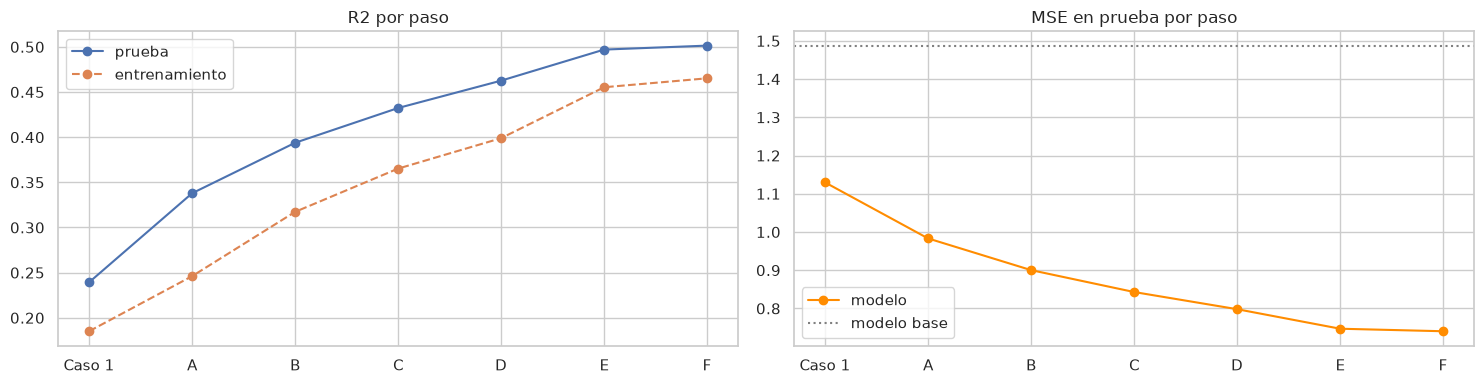

In [31]:
# Evolucion de R2 y MSE a medida que se agregan variables
etiquetas = ["Caso 1", "A", "B", "C", "D", "E", "F"]
fig, ejes = plt.subplots(1, 2, figsize=(15, 4))
ejes[0].plot(etiquetas, tabla["R2_test"], marker="o", label="prueba")
ejes[0].plot(etiquetas, tabla["R2_train"], marker="o", ls="--", label="entrenamiento")
ejes[0].set_title("R2 por paso")
ejes[0].legend()
ejes[1].plot(etiquetas, tabla["MSE_test"], marker="o", color="darkorange", label="modelo")
ejes[1].axhline(mse_base, color="gray", ls=":", label="modelo base")
ejes[1].set_title("MSE en prueba por paso")
ejes[1].legend()
plt.tight_layout()
plt.show()

In [32]:
# Coeficientes del paso A (solo dos variables)
modelo_a, pred_a, cols_a = modelos["Paso A: " + " + ".join(par)]
print("Intercepto:", round(modelo_a.intercept_, 4))
print(pd.Series(modelo_a.coef_, index=cols_a).round(4))

Intercepto: 1.7548
es_serie         0.8888
puntaje_texto    0.6841
dtype: float64


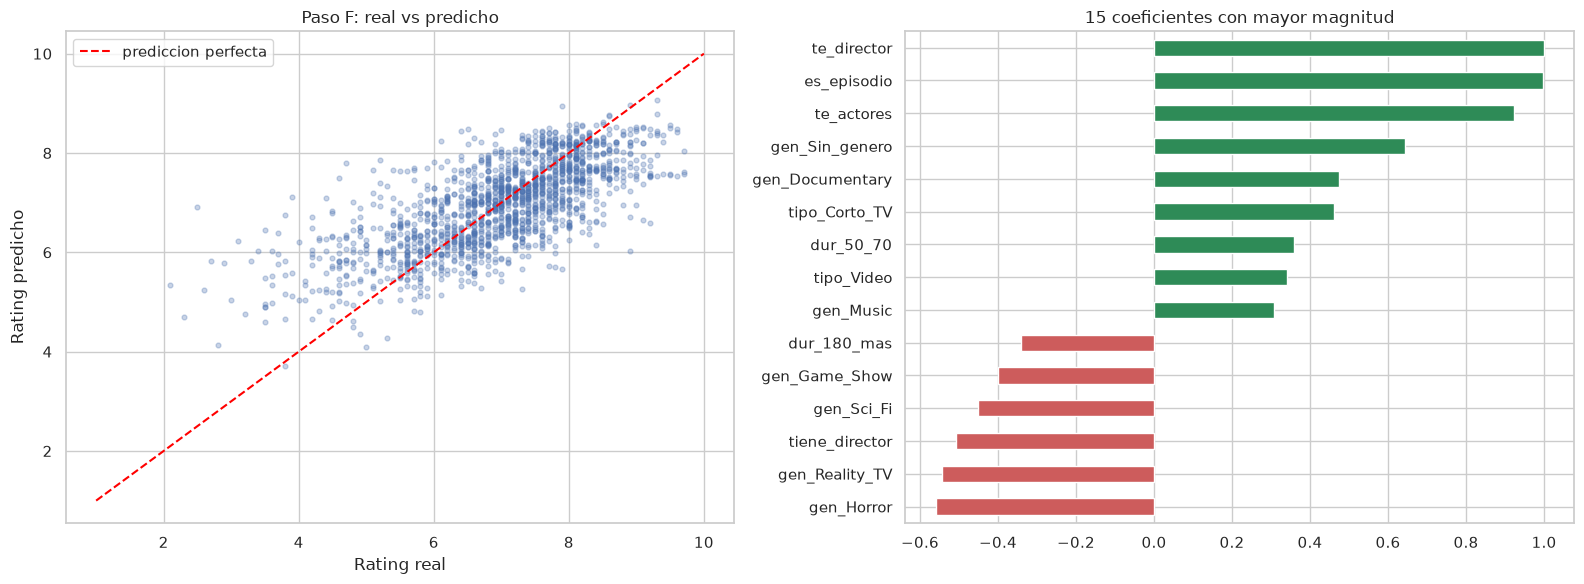

In [33]:
# Modelo final: real vs predicho y coeficientes con mayor magnitud
modelo_f, pred_f, cols_f = modelos["Paso F: + rangos de duracion"]

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))
ejes[0].scatter(test["rating"], pred_f, alpha=0.3, s=12)
ejes[0].plot([1, 10], [1, 10], color="red", ls="--", label="prediccion perfecta")
ejes[0].set_xlabel("Rating real")
ejes[0].set_ylabel("Rating predicho")
ejes[0].set_title("Paso F: real vs predicho")
ejes[0].legend()

coef = pd.Series(modelo_f.coef_, index=cols_f)
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15).sort_values()
top.plot(kind="barh", ax=ejes[1], color=np.where(top > 0, "seagreen", "indianred"))
ejes[1].set_title("15 coeficientes con mayor magnitud")
plt.tight_layout()
plt.show()

### Análisis de residuos del modelo final

**Concepto: residuo.** Es la diferencia entre el rating real y el predicho. Si el modelo está bien planteado, los residuos quedan repartidos alrededor de cero sin ningún patrón. Si se ve una forma, el modelo se equivoca de manera sistemática en alguna zona.

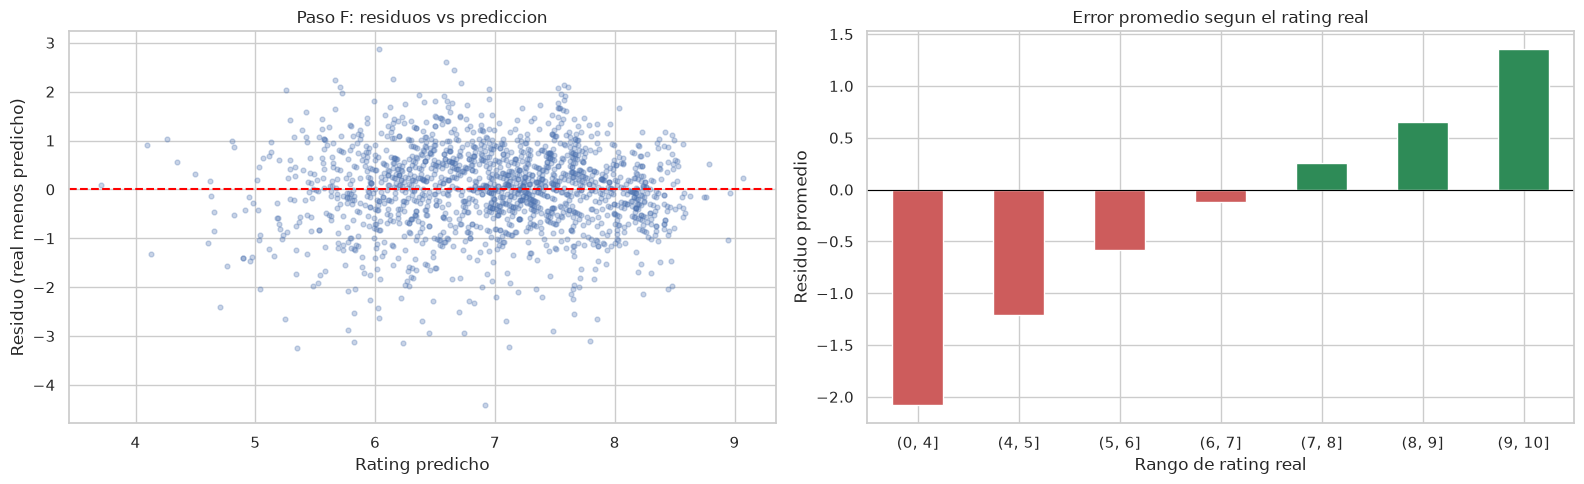

rating
(0, 4]    -2.080
(4, 5]    -1.206
(5, 6]    -0.581
(6, 7]    -0.120
(7, 8]     0.254
(8, 9]     0.651
(9, 10]    1.356
Name: rating, dtype: float64


In [34]:
# Residuos contra la prediccion y residuo promedio segun el rating real
residuos_f = test["rating"] - pred_f

fig, ejes = plt.subplots(1, 2, figsize=(16, 5))
ejes[0].scatter(pred_f, residuos_f, alpha=0.3, s=12)
ejes[0].axhline(0, color="red", ls="--")
ejes[0].set_xlabel("Rating predicho")
ejes[0].set_ylabel("Residuo (real menos predicho)")
ejes[0].set_title("Paso F: residuos vs prediccion")

rangos = pd.cut(test["rating"], bins=[0, 4, 5, 6, 7, 8, 9, 10])
res_rango = residuos_f.groupby(rangos, observed=True).mean()
res_rango.plot(kind="bar", ax=ejes[1], rot=0, color=np.where(res_rango > 0, "seagreen", "indianred"))
ejes[1].axhline(0, color="black", lw=0.8)
ejes[1].set_xlabel("Rango de rating real")
ejes[1].set_ylabel("Residuo promedio")
ejes[1].set_title("Error promedio segun el rating real")
plt.tight_layout()
plt.show()
print(res_rango.round(3))

Los residuos tienen un patrón claro. Para los títulos con rating real menor a 4 el modelo se pasa en promedio por 2.1 puntos, y para los de más de 9 se queda corto por 1.4 puntos. En los rangos centrales, entre 6 y 8, el error promedio es cercano a cero.

El modelo tira siempre hacia el centro: sobreestima los títulos malos y subestima los muy buenos. Esto ocurre cuando las variables disponibles no alcanzan a explicar por qué un título es excepcional; en ese caso, lo que minimiza el error cuadrático es quedarse cerca del promedio. Es la principal razón del techo que tiene el modelo.

### Conclusiones del caso 2

La pareja escogida por validación cruzada fue `es_serie` y `puntaje_texto`. Con solo esas dos variables el R² en prueba sube de 0.239 a 0.338 y el MSE baja de 1.130 a 0.983. El coeficiente de `puntaje_texto` es 0.68: por cada punto que sube la predicción hecha con la sinopsis, el rating esperado sube 0.68 puntos, una vez descontado el efecto de ser serie.

Cada grupo de variables mejoró el modelo:

1. Duración, votos y estructura del título (paso B): R² de 0.394.
2. Datos adicionales (paso C): R² de 0.432.
3. Historial del director y los actores (paso D): R² de 0.463.
4. Géneros y tipo (paso E): R² de 0.497.
5. Rangos de duración (paso F): R² de **0.501**, con MSE de 0.740 y RMSE de 0.86 puntos, contra 1.22 del modelo base.

El paso D muestra que las variables construidas a partir del reparto aportan información que no estaba en ninguna otra columna. Los rangos de duración suman poco (0.004), pero confirman que la discretización permite capturar parte de la relación no lineal con la duración.

Entre los coeficientes del modelo final, los más grandes son los de `te_director`, `es_episodio` y `te_actores` (positivos, cercanos a 1): un director o un reparto cuyas otras obras tienen un punto más de rating se asocian con cerca de un punto más en el título. Les siguen géneros como terror, reality y ciencia ficción (negativos) y documental (positivo).

No hay sobreajuste: el R² de entrenamiento y el de prueba se mantienen cercanos en todos los pasos (0.465 y 0.501 en el modelo final). La regresión lineal es un modelo simple y hay más de 6500 filas para 63 coeficientes.

## 8. Conclusiones generales

1. Con una sola variable (`es_serie`) la regresión lineal explica el 24 % de la variación del rating. Con la limpieza, las variables derivadas y el historial del reparto se llega al **50 %** (R² de 0.501) y el error típico baja de 1.22 a 0.86 puntos.
2. La limpieza fue decisiva. Las variables más útiles (`es_serie`, `es_episodio`, el tipo, los géneros, la lista de directores y actores y la sinopsis sin relleno) no existían como columnas y hubo que construirlas a partir del texto.
3. Las variables construidas con TF IDF y codificación por objetivo fueron de las más útiles: el puntaje de la sinopsis formó parte de la mejor pareja del caso 2 y el historial del reparto sumó 0.03 de R² en el paso D. Todas se calcularon fuera de pliegue para que el modelo nunca viera el rating del mismo título.
4. El R² no puede subir mucho más con estos datos. Lo que más determina la nota de un título (la calidad del guion, la actuación o la producción) no está en el dataset, y además dos títulos casi iguales pueden tener notas muy distintas. El análisis de residuos muestra que el modelo no logra explicar los títulos excepcionales.
5. La división de entrenamiento y prueba agrupada por título evita que el modelo se aproveche de ver episodios de la misma serie en ambos conjuntos, así que las métricas reportadas son una estimación honesta del desempeño con títulos nuevos.